In [1]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from simulator_fn import *
from simulator_random import * 

In [2]:
simulation_time = 100
resolution = 1e-3
nsamples = int(simulation_time/resolution)
nneurons = 20
plot_window = slice(60.0, 80.0)
d = 2
print(nsamples)

100000


In [3]:
neuron_amounts = (0, 0, 0, 0, 0, 12, 6, 2)
neuron_type_names = ["ISe", "ISi", "ISB", "IFB", "A", "RS", "RSB", "RFB"]
neuron_names = []
for type_name, type_amount in zip(neuron_type_names, neuron_amounts):
    neuron_names += [f"{i+1:2d} {type_name:3}" for i in range(type_amount)]
    
neuron_names

[' 1 RS ',
 ' 2 RS ',
 ' 3 RS ',
 ' 4 RS ',
 ' 5 RS ',
 ' 6 RS ',
 ' 7 RS ',
 ' 8 RS ',
 ' 9 RS ',
 '10 RS ',
 '11 RS ',
 '12 RS ',
 ' 1 RSB',
 ' 2 RSB',
 ' 3 RSB',
 ' 4 RSB',
 ' 5 RSB',
 ' 6 RSB',
 ' 1 RFB',
 ' 2 RFB']

In [4]:
sim = run_simulator_random(simulation_time=simulation_time)

/tmp/ipykernel_688283/584479695.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(


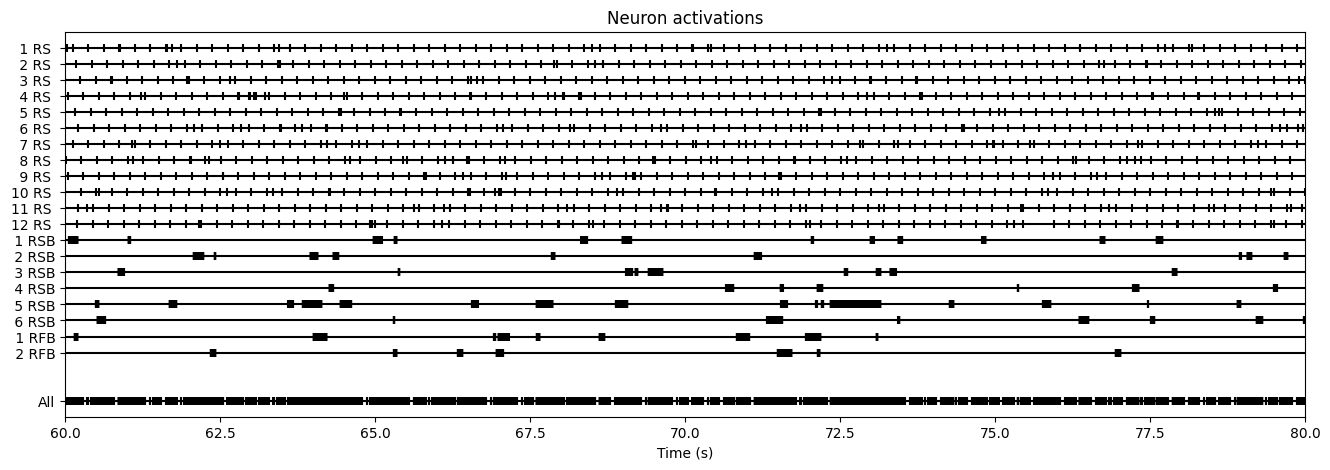

In [5]:
fig, ax = plt.subplots(1,1, figsize=(16,5))

voffset = 3
yticks = len(sim) - np.arange(len(sim)) + voffset
yticks = list(yticks) + [1]

ax.axhline(1, color='k')
for idx, sim_n in enumerate(sim):
    h = len(sim) - idx + voffset
    sim_n_arr = np.asarray(sim_n)
    sim_n_arr = sim_n_arr[(sim_n_arr > plot_window.start) | (sim_n_arr < plot_window.stop)]
    ax.axhline(h, color='k')
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, h), marker="|", color="k")
    ax.scatter(sim_n_arr, np.full_like(sim_n_arr, 1), marker="|", color="k")
    
ax.set(
    xlim=(plot_window.start, plot_window.stop),
    xlabel="Time (s)",
    ylim=(0, len(sim)+voffset+1),
    title="Neuron activations",
    yticklabels=neuron_names + ["All"],
    yticks=yticks
)
plt.show()

0.26


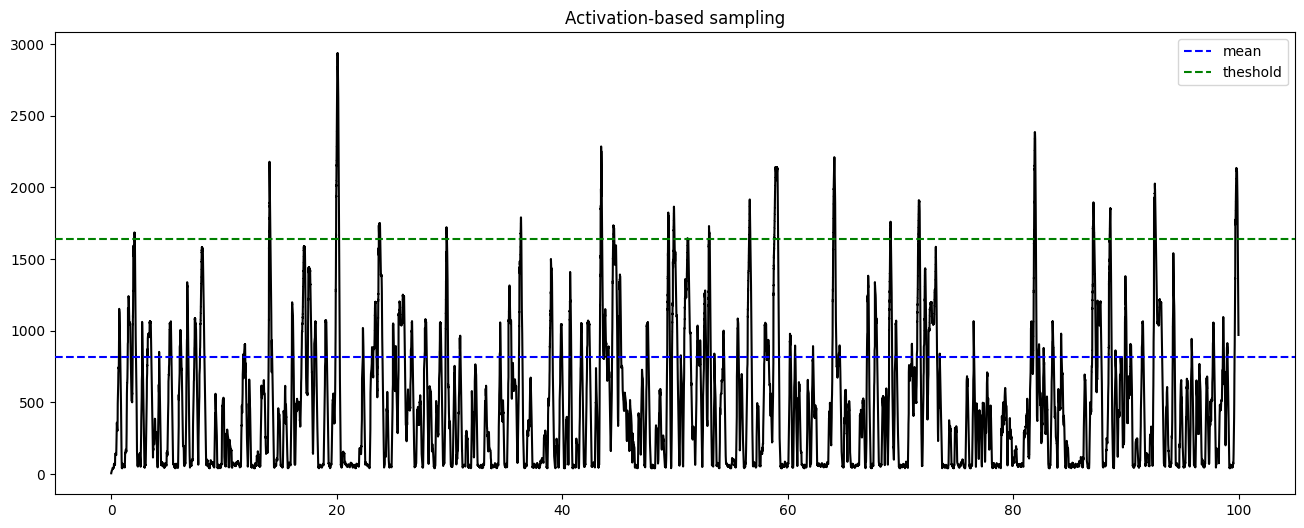

In [8]:
collapsed_sim = np.asarray(sorted(sum(sim, start=[])))
freq_ts = calculate_frequency(sim, simulation_time=simulation_time, bin_size=0.2, return_counts=False)
window_len = len(freq_ts)//10
signal_mean = np.mean(freq_ts)
# signal_offset = np.std(freq_ts)
signal_offset = np.mean(freq_ts) * (d-1)/d

print(count_peaks_mean(freq_ts, d=d)/simulation_time)

fig, ax = plt.subplots(1,1, figsize=(16,6))
plt.plot(collapsed_sim, freq_ts, color='k')
if np.asarray(signal_mean).size == 1:
    plt.axhline(signal_mean, c="blue", ls="--", label="mean", zorder=10)
    plt.axhline(signal_mean+d*signal_offset, c="green", ls="--", label="theshold", zorder=10)
else:
    plt.plot(collapsed_sim, signal_mean, c="blue", ls="--", label="mean", zorder=10)
    plt.plot(collapsed_sim, signal_mean+d*signal_offset, c="green", ls="--", label="theshold", zorder=10)

plt.title("Activation-based sampling")
plt.legend()
plt.show()

[]

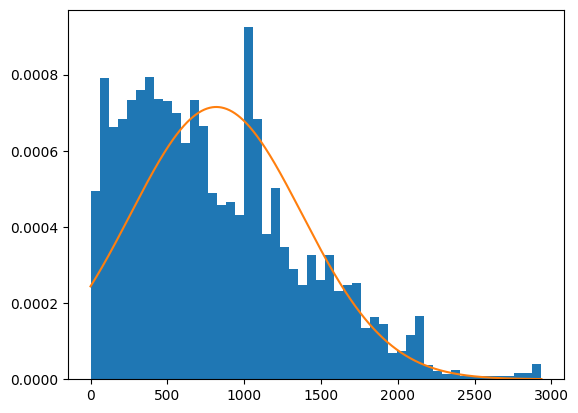

In [9]:
fig, ax = plt.subplots()
ax.hist(freq_ts, bins=50, density=True)
# sns.kdeplot(freq_ts, ax=ax)
x = np.linspace(0, max(freq_ts), 1000)
ax.plot(x, sp.stats.norm(loc=freq_ts.mean(), scale=freq_ts.std()).pdf(x))
plt.plot()